# Классификация риса (арборио и басмати)

In [ ]:
!pip install split-folders
!pip install torchview

In [ ]:
import os
import shutil
import numpy as np
import random
from PIL import Image
import splitfolders

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator    # Генератор обучающих данных
from tensorflow.keras.models import Sequential      # Контейнер модели
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense  # Типы используемых слоев
from tensorflow.keras.optimizers import Adam    # Алгоритм оптимизации
import matplotlib.pyplot as plt
from zipfile import ZipFile

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import Dropout, BatchNorm2d
from tqdm import tqdm
from torchview import draw_graph

In [ ]:
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 64
NUM_EPOCHS = 30

In [ ]:
zip_path = '/content/drive/MyDrive/Rice_arborio_vs_basmati.zip'
dataset_dir = r'/content/3. Rice - arborio vs basmati'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
print(f"Arborio images count = {len(os.listdir(os.path.join(dataset_dir, 'Arborio')))}")
print(f"Basmati images count = {len(os.listdir(os.path.join(dataset_dir, 'Basmati')))}")

Arborio images count = 2000
Basmati images count = 1855


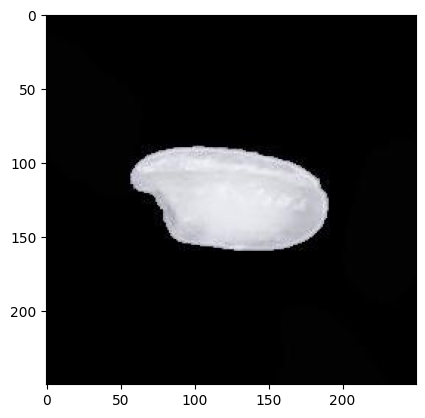

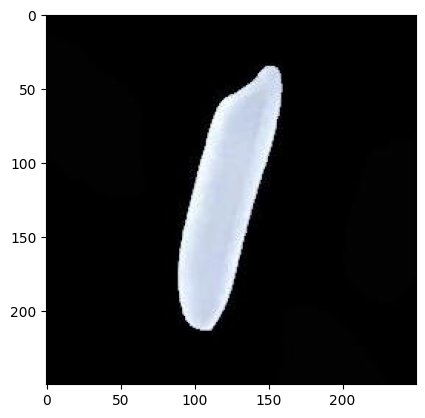

In [ ]:
plt.imshow(Image.open(os.path.join(dataset_dir, 'Arborio', 'Arborio (1).jpg')))
plt.show()

plt.imshow(Image.open(os.path.join(dataset_dir, 'Basmati', 'Basmati (1).jpg')))
plt.show()

In [ ]:
splitfolders.ratio(
    f"{dataset_dir}",
    output=f"{dataset_dir}-split",
    seed=42,
    ratio=(0.6, 0.2, 0.2),
    group_prefix=None
)

Copying files: 3855 files [00:00, 5210.54 files/s]


## TensorFlow

### Предобработка данных

In [ ]:
# Аугментация для тренировочных данных. Помогает модели выделять устойчивые признаки
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, # Нормирование
    rotation_range=20, # Вращение на случайный угол до 20 градусов
    width_shift_range=0.2, # Случайный сдвиг по ширине до 20%
    height_shift_range=0.2, # Случайный сдвиг по высоте до 20%
    horizontal_flip=True, # Случайное горизонтальное отражение
    zoom_range=0.2, # Случайный зум до 20%
    shear_range=0.2,
    fill_mode='nearest' # Заполнение пустых мест ближайшими пикселями
)

# Только рескейлинг для валидации и теста
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [ ]:
# Генераторы данных. Загрузка и аугментация данных во время работы
train_generator = train_datagen.flow_from_directory(
    f"{dataset_dir}-split/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    f"{dataset_dir}-split/val",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    f"{dataset_dir}-split/test",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Классы: {train_generator.class_indices}")
print(f"Размер тренировочной выборки: {train_generator.samples}")
print(f"Размер валидационной выборки: {validation_generator.samples}")
print(f"Размер тестовой выборки: {test_generator.samples}")

Found 2313 images belonging to 2 classes.
Found 771 images belonging to 2 classes.
Found 771 images belonging to 2 classes.
Классы: {'Arborio': 0, 'Basmati': 1}
Размер тренировочной выборки: 2313
Размер валидационной выборки: 771
Размер тестовой выборки: 771


### Построение и обучение модели

In [ ]:
model = tf.keras.Sequential([
  # Слой 1: 32 фильтра, ядро 3x3
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  tf.keras.layers.MaxPooling2D((2, 2)),

  # Слой 2: 64 фильтра, ядро 3x3
  tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),

  # Слой 3: 128 фильтров, ядро 3x3
  tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),

  # Переход к полносвязным слоям
  tf.keras.layers.Flatten(),

  # Полносвязный слой 1: 64 нейрона
  tf.keras.layers.Dense(64, activation='relu'),

  # Полносвязный слой 2: 128 нейронов
  tf.keras.layers.Dense(128, activation='relu'),

  # Выходной слой: 2 класса
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,367,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,469,249 (9.42 MB)

 Trainable params: 2,469,249 (9.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath='models/best_custom_model.h5',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6190 - loss: 0.6580
Epoch 1: val_loss improved from inf to 0.40098, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 519ms/step - accuracy: 0.6206 - loss: 0.6567 - val_accuracy: 0.8210 - val_loss: 0.4010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8076 - loss: 0.4473
Epoch 2: val_loss improved from 0.40098 to 0.14057, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 403ms/step - accuracy: 0.8088 - loss: 0.4452 - val_accuracy: 0.9935 - val_loss: 0.1406
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9091 - loss: 0.2342
Epoch 3: val_loss improved from 0.14057 to 0.09333, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 404ms/step - accuracy: 0.9093 - loss: 0.2336 - val_accuracy: 0.9870 - val_loss: 0.0933
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9455 - loss: 0.1573
Epoch 4: val_loss improved from 0.09333 to 0.05381, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 406ms/step - accuracy: 0.9455 - loss: 0.1572 - val_accuracy: 1.0000 - val_loss: 0.0538
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9496 - loss: 0.1386
Epoch 5: val_loss did not improve from 0.05381
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step - accuracy: 0.9496 - loss: 0.1383 - val_accuracy: 0.9546 - val_loss: 0.1158
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9637 - loss: 0.1069
Epoch 6: val_loss improved from 0.05381 to 0.01187, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 420ms/step - accuracy: 0.9638 - loss: 0.1066 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9639 - loss: 0.0925
Epoch 7: val_loss did not improve from 0.01187
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 421ms/step - accuracy: 0.9640 - loss: 0.0925 - val_accuracy: 0.9935 - val_loss: 0.0606
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9649 - loss: 0.0841
Epoch 8: val_loss did not improve from 0.01187
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step - accuracy: 0.9650 - loss: 0.0838 - val_accuracy: 1.0000 - val_loss: 0.0208
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9763 - loss: 0.0648
Epoch 9: val_loss improved from 0.01187 to 0.00395, saving model to models/best_custom_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 402ms/step - accuracy: 0.9763 - loss: 0.0649 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9705 - loss: 0.0795
Epoch 10: val_loss did not improve from 0.00395
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step - accuracy: 0.9707 - loss: 0.0792 - val_accuracy: 0.9987 - val_loss: 0.0062
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9816 - loss: 0.0478
Epoch 11: val_loss did not improve from 0.00395
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 394ms/step - accuracy: 0.9815 - loss: 0.0481 - val_accuracy: 0.9974 - val_loss: 0.0078
Epoch 12/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9775 - loss: 0.0577
Epoch 12: val_loss did not improve from 0.00395
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step - accuracy: 0.9775 - loss: 0.0577 - val_accuracy: 0.9935 - val_loss: 0.0160
Epoch 13/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9822 - loss: 0.0528
Epoch 13: val_loss did not improve f

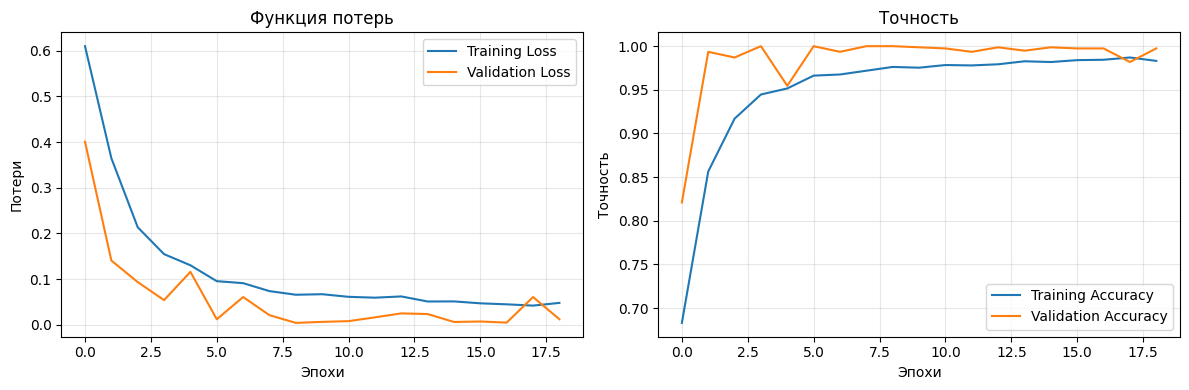

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Validation Loss')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(model_history.history['accuracy'], label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

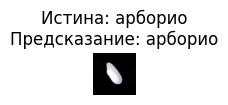

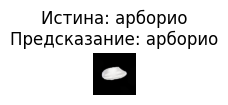

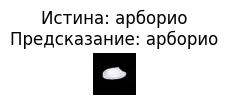

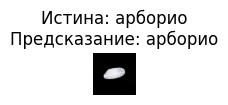

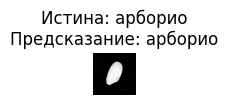

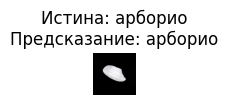

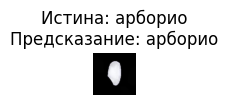

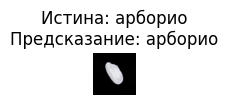

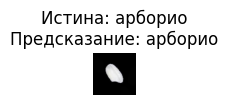

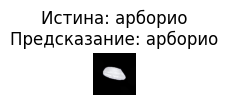

In [ ]:
test_images, test_labels = next(test_generator)
num_demo = min(10, BATCH_SIZE)

for i in range(num_demo):
  image = test_images[i]
  true_label = "арборио" if test_labels[i] == 0 else "басмати"

  prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]

  predicted_class = "арборио" if prediction < 0.5 else "басмати"

  plt.subplot(1, num_demo, i + 1)
  plt.imshow(image)
  plt.title(f'Истина: {true_label}\nПредсказание: {predicted_class}')
  plt.axis('off')
  plt.show()

## PyTorch

In [ ]:
transforms_train = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Создаем датасеты
dataset_train = datasets.ImageFolder(f"{dataset_dir}-split/train", transforms_train)
dataset_val = datasets.ImageFolder(f"{dataset_dir}-split/val", transforms_train)
dataset_test = datasets.ImageFolder(f"{dataset_dir}-split/test", transforms_test)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=2)
dataloader_val = DataLoader(dataset_val, batch_size=32, shuffle=True, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# Get dataset sizes and class names
dataset_sizes_train = len(dataset_train)
dataset_sizes_val = len(dataset_val)
dataset_sizes_test = len(dataset_test)
class_names = dataset_train.classes
print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes_train}, {dataset_sizes_val}, {dataset_sizes_test}")

Classes: ['Arborio', 'Basmati']
Dataset sizes: 2313, 771, 771


In [ ]:
class RiceCNN(nn.Module):
    def __init__(self):
        super(RiceCNN, self).__init__()
        self.nn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2048, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out = self.nn(x)
        return out

model_pt = RiceCNN()

In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
LEARNING_RATE_PT = 0.00005
optimizer = optim.Adam(model_pt.parameters(), lr=LEARNING_RATE_PT)

In [ ]:
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels.float().unsqueeze(1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels.float().unsqueeze(1)).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    model.eval()
    with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            test_total_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            test_correct += (predicted == labels.float().unsqueeze(1)).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_pt.to(device)

Using device: cuda


RiceCNN(
  (nn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16):

In [ ]:
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(NUM_EPOCHS):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model_pt, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")


Epoch 1/30, Loss: 0.6457, Accuracy: 0.7428, Test Loss: 0.4116, Test Accuracy: 0.9909



Epoch 2/30, Loss: 0.0743, Accuracy: 0.9948, Test Loss: 0.0064, Test Accuracy: 1.0000



Epoch 3/30, Loss: 0.0052, Accuracy: 0.9987, Test Loss: 0.0021, Test Accuracy: 1.0000



Epoch 4/30, Loss: 0.0040, Accuracy: 0.9987, Test Loss: 0.0280, Test Accuracy: 0.9909



Epoch 5/30, Loss: 0.0057, Accuracy: 0.9978, Test Loss: 0.0011, Test Accuracy: 1.0000


...


Epoch 26/30, Loss: 0.0000, Accuracy: 1.0000, Test Loss: 0.0001, Test Accuracy: 1.0000



Epoch 27/30, Loss: 0.0000, Accuracy: 1.0000, Test Loss: 0.0001, Test Accuracy: 1.0000



Epoch 28/30, Loss: 0.0000, Accuracy: 1.0000, Test Loss: 0.0001, Test Accuracy: 1.0000



Epoch 29/30, Loss: 0.0000, Accuracy: 1.0000, Test Loss: 0.0001, Test Accuracy: 1.0000



Epoch 30/30, Loss: 0.0000, Accuracy: 1.0000, Test Loss: 0.0001, Test Accuracy: 1.0000


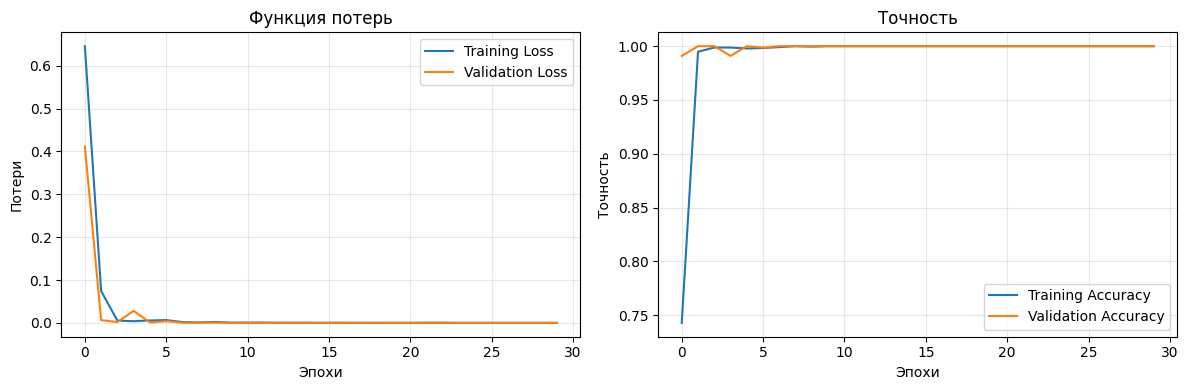

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()